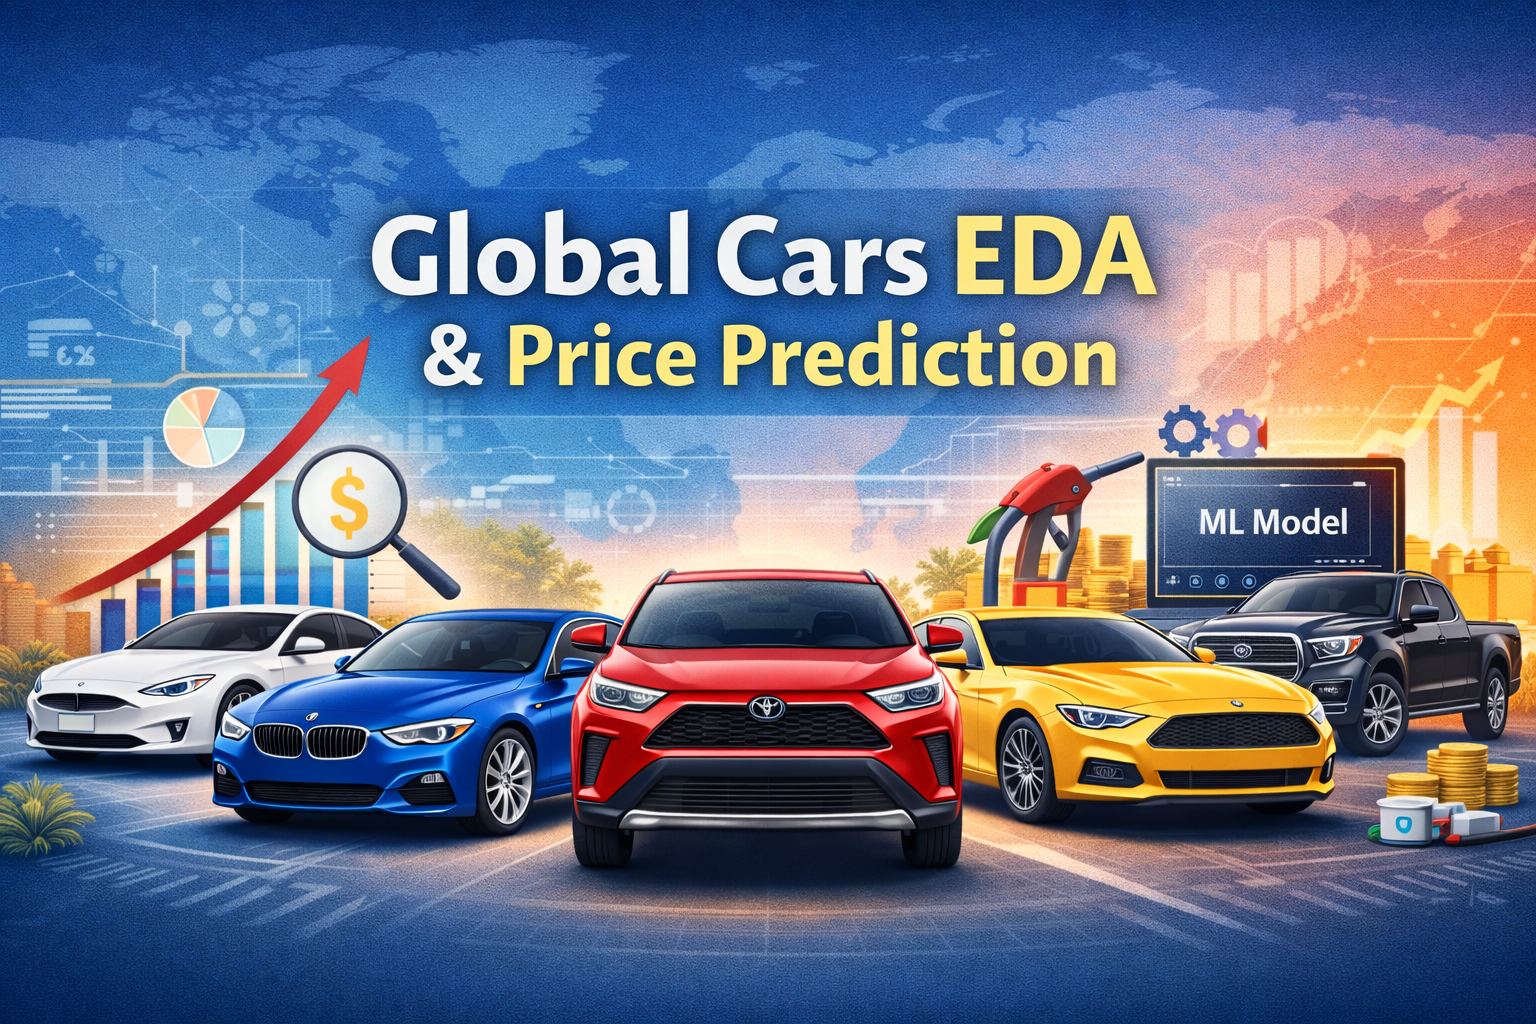

In [1]:
from IPython.display import Image, display
display(Image(filename='/kaggle/input/cars-image/ChatGPT Image Feb 4 2026 10_18_58 PM.png'))

# 🚗 Global Cars Dataset – EDA & Price Prediction
This notebook performs **Exploratory Data Analysis (EDA)** and builds a **Machine Learning model to predict car prices**.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

df = pd.read_csv('/kaggle/input/global-cars-data/global_cars_dataset_synthetic.csv')
df.head()

,Car_ID,Brand,Manufacture_Year,Body_Type,Fuel_Type,Transmission,Engine_CC,Horsepower,Mileage_km_per_l,Price_USD,Manufacturing_Country
0,CAR_0001,Mercedes,2006,SUV,Petrol,Manual,4089,547,17,73407,USA
1,CAR_0002,Nissan,2023,Coupe,Petrol,Automatic,4618,167,25,79370,USA
2,CAR_0003,Nissan,2007,Hatchback,Diesel,Manual,1802,110,16,76549,China
3,CAR_0004,Nissan,2013,Coupe,Petrol,Manual,1835,373,16,48722,USA
4,CAR_0005,Hyundai,2009,Hatchback,Hybrid,Automatic,2332,145,28,83265,UK


## 📊 Exploratory Data Analysis

In [3]:
df.describe()

,Manufacture_Year,Engine_CC,Horsepower,Mileage_km_per_l,Price_USD
count,300.000000,300.000000,300.000000,300.000000,300.000000
mean,2015.123333,3052.880000,328.346667,19.716667,60848.823333
std,5.966023,1117.937497,153.202644,6.028061,34445.525598
min,2005.000000,1001.000000,70.000000,10.000000,5221.000000
25%,2010.000000,2074.000000,188.250000,15.000000,29418.500000
50%,2015.000000,3117.500000,329.500000,19.500000,59179.500000
75%,2020.000000,3964.000000,454.750000,24.000000,89692.250000
max,2025.000000,4994.000000,599.000000,30.000000,119587.000000


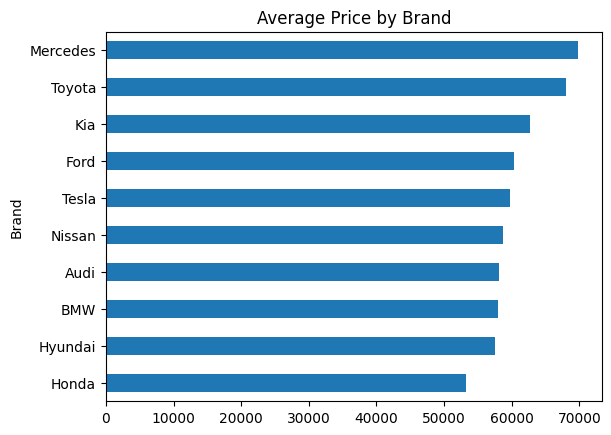

In [4]:
df.groupby('Brand')['Price_USD'].mean().sort_values().plot(kind='barh')
plt.title('Average Price by Brand')
plt.show()

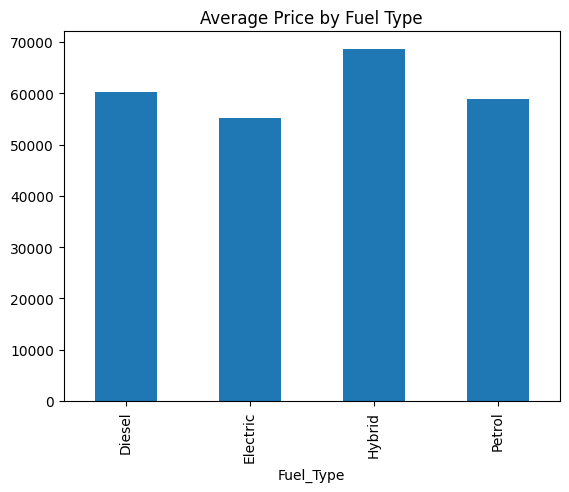

In [5]:
df.groupby('Fuel_Type')['Price_USD'].mean().plot(kind='bar')
plt.title('Average Price by Fuel Type')
plt.show()

## 🤖 Machine Learning – Price Prediction

In [6]:
X = df.drop(columns=['Price_USD','Car_ID'])
y = df['Price_USD']

categorical = X.select_dtypes(include='object').columns
numeric = X.select_dtypes(exclude='object').columns

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical),
    ('num', 'passthrough', numeric)
])

model = RandomForestRegressor(n_estimators=200, random_state=42)

pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', model)
])

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
pipeline.fit(X_train, y_train)

preds = pipeline.predict(X_test)
print('MAE:', mean_absolute_error(y_test, preds))
print('R2 Score:', r2_score(y_test, preds))

MAE: 30355.109
R2 Score: -0.033400627597838906


## ✅ Conclusion
- Random Forest captures nonlinear relationships well
- Dataset is suitable for regression & feature importance analysis
- Can be extended with depreciation, resale value, emissions